## **Duffing oscillator (SINDy)**


## **I. Setup and Preprocessing**


In [2]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import sys
sys.path.append('../utilities')

import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps
import DataGenerator as DG


### **1.2 Training Data**


#### Create dataset


[3.48357077 0.30867849]
Guess highest order polynomial: 3


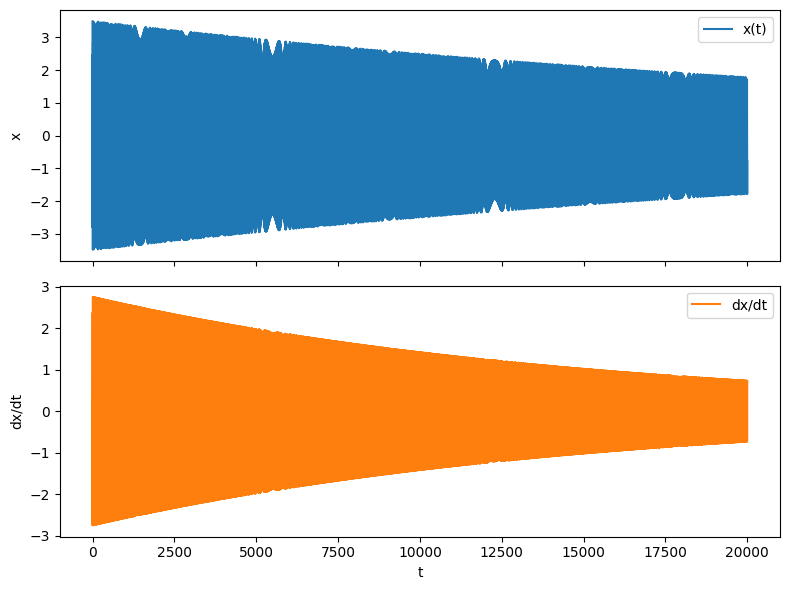

Training input shape: (10000, 2)
Training output shape: (10000, 2)


In [18]:
# Specify the model type
MY_MODEL = 'duffing'

SEED = 42  # set seed for random number generation
np.random.seed(SEED)

# Generate data based on the specified model type
num_traj = 1
data_initial_conditions = []
for i in range(num_traj):
    x0 = np.random.normal(1, 5.0, size=2)  # [x, dx/dt]
    data_initial_conditions.append(x0)

print(data_initial_conditions[0])

data_T = 20000.0       # Length of the data (T)
data_dt = 2    # Resolution of the data (dt)
myDG = DG.DataGenerator(data_initial_conditions, T=data_T, dt=data_dt, random_state=SEED)

duffing_p = [0.0001, 0.01, 0.1]  # [damping, linear, cubic]
t_arr, x_train, dx_train, guess_highest_order_polynomial = myDG.generate_dataset_by_model_name(
    MY_MODEL, duffing_p, method='DOP853'
)

print('Guess highest order polynomial:', guess_highest_order_polynomial)

# Plot response for the first trajectory
steps = t_arr.shape[0]
t_plot = t_arr.squeeze()
x_first = x_train[:steps, 0]
xdot_first = x_train[:steps, 1]

fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(t_plot, x_first, label='x(t)')
ax[0].set_ylabel('x')
ax[0].legend()
ax[1].plot(t_plot, xdot_first, label='dx/dt', color='tab:orange')
ax[1].set_ylabel('dx/dt')
ax[1].set_xlabel('t')
ax[1].legend()
plt.tight_layout()
plt.show()

# Shuffle data
training_input, training_output = x_train, dx_train

print('Training input shape:', training_input.shape)
print('Training output shape:', training_output.shape)


## **II. SINDy Fit**


In [31]:
# Build polynomial library and fit SINDy model
library = ps.PolynomialLibrary(degree=3, include_bias=True)
optimizer = ps.STLSQ(threshold=0.00009)
model = ps.SINDy(feature_library=library, optimizer=optimizer)

steps = t_arr.shape[0]
x_list = [x_train[i * steps:(i + 1) * steps] for i in range(num_traj)]
dx_list = [dx_train[i * steps:(i + 1) * steps] for i in range(num_traj)]

model.fit(x_list if num_traj > 1 else x_train,
          t=data_dt,
          x_dot=dx_list if num_traj > 1 else dx_train)

model.print()


(x0)' = 1.000 x1
(x1)' = -0.010 x0 + -0.100 x0^3


### **Validation**


In [ ]:
# Compare derivatives
pred_x_dot = model.predict(x_train)

fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(t_plot, pred_x_dot[:steps, 0], label='SINDy')
ax[0].plot(t_plot, dx_train[:steps, 0], '--', label='True')
ax[0].set_ylabel('dx/dt')
ax[0].legend()
ax[1].plot(t_plot, pred_x_dot[:steps, 1], label='SINDy')
ax[1].plot(t_plot, dx_train[:steps, 1], '--', label='True')
ax[1].set_ylabel('d^2x/dt^2')
ax[1].set_xlabel('t')
ax[1].legend()
plt.tight_layout()
plt.show()

# Simulate and compare response
x0 = data_initial_conditions[0]
x_sim = model.simulate(x0, t_plot)

fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(t_plot, x_sim[:, 0], label='SINDy')
ax[0].plot(t_plot, x_train[:steps, 0], '--', label='True')
ax[0].set_ylabel('x')
ax[0].legend()
ax[1].plot(t_plot, x_sim[:, 1], label='SINDy')
ax[1].plot(t_plot, x_train[:steps, 1], '--', label='True')
ax[1].set_ylabel('dx/dt')
ax[1].set_xlabel('t')
ax[1].legend()
plt.tight_layout()
plt.show()
